In [1]:
# import jupyter_black

# jupyter_black.load()

# Dataset 2

- Please extract dataset2.zip into the directory "data"

In [2]:
# data_option = "dataset1"
data_option = "dataset2"

## Initial setup

In [3]:
from speciesot import configure_platform, Config, Data, SpeciesOT

In [4]:
configure_platform()
# configure_platform("gpu")
# configure_platform("cpu")

JAX is configured to use: METAL


### Computational parameters

In [5]:
if data_option == "dataset1":
    mask_option = "time_series_data"
    threshold = 3.0
    threshold_surer = 3.5
    high_epsilon = 0.01

elif data_option == "dataset2":
    mask_option = "one_time_point_data"
    threshold = 1.4
    threshold_surer = 2.5
    high_epsilon = 0.1

elif data_option == "custom":
    mask_option = "one_time_point_data"
    threshold = 1.4
    threshold_surer = 2.5
    high_epsilon = 0.01

In [6]:
iterations = 1000
threshold_eps = 1e-4
low_epsilon = 0.0
threshold_tol = 3.0

In [7]:
if data_option == "dataset1":
    species = ["human", "macaque", "mouse"]
    species_pairs = []
    species_labels = ["Human", "Macaque", "Mouse"]

elif data_option == "dataset2":
    species = ["human", "chimpanzee", "gorilla", "orangutan", "macaque", "mouse"]
    species_pairs = []
    species_labels = [
        "Human_iPSC(AK02)",
        "Chimp_iPSC(AK02)",
        "Gorilla_iPSC(AITS)",
        "Orang_iPSC(AITS)",
        "Macaque_ESC(AITS)",
        "Mouse_EpiLC",
    ]

elif data_option == "custom":
    species = ["animal1", "animal2", "animal3"]
    species_pairs = []
    species_labels = ["Animal1", "Animal2", "Animal3"]

## Initialize the Config() class

In [8]:
if data_option == "dataset1":
    config = Config(
        "dataset1",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )

elif data_option == "dataset2":
    config = Config(
        "dataset2",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )

elif data_option == "custom":
    config = Config(
        data_option="custom",
        mouse_option="drop",
        gene_option="distinct",
        threshold_option="auto",
        metric_option="euclidean",
        dismat_option="original",
        gwot_option="fixed",
        mask_option=mask_option,
        iterations=iterations,
        threshold_eps=threshold_eps,
        low_epsilon=low_epsilon,
        high_epsilon=high_epsilon,
        threshold_tol=threshold_tol,
        threshold=threshold,
        threshold_surer=threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )

## Initialize the Data() class

In [9]:
data = Data(config)

### Read CSV file

In [10]:
data = data.read_csv()

### Geometrization steps (noise reduction and total count normalization)

In [11]:
data = data.normalization()

start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(16535), '#non-significant genes': np.int64(15612), '#silent genes': np.int64(0), 'ell': np.int64(65), 'Elapsed time': '0h 0m 8s 783ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15569), '#non-significant genes': np.int64(12952), '#silent genes': np.int64(0), 'ell': np.int64(32), 'Elapsed time': '0h 0m 1s 841ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15118), '#non-significant genes': np.int64(14736), '#silent genes': np.int64(0), 'ell': np.int64(66), 'Elapsed time': '0h 0m 11s 549ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(14588), '#non-significant genes': np.int64(14096), '#silent genes': np.int64(

### Geometrization step (gene selection using human transcription factors)

In [12]:
data = data.read_tf()

#genes in hTF.txt
1639


## Initialize the SpeciesOT() class

In [13]:
spe_ot = SpeciesOT(data)

### Geometrization step (filtering)

In [14]:
spe_ot = spe_ot.preprocessing()

### Geometrization step (distance matrix computation)

In [15]:
spe_ot = spe_ot.calculate_gene_distance_matrix()

### Entropically regularized Gromov-Wasserstein optimal transport

In [16]:
spe_ot = spe_ot.gromov_wasserstein_ot()

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1761124252.644878 5162973 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1761124252.658124 5162973 service.cc:145] XLA service 0x10d68bee0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761124252.658138 5162973 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1761124252.659600 5162973 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1761124252.659618 5162973 mps_client.cc:384] XLA backend will use up to 103078739968 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M3 Max

systemMemory: 128.00 GB
maxCacheSize: 48.00 GB

epsilon = 0.1000000 converged


### Normalized optimal transport plan

In [17]:
spe_ot = spe_ot.normalize_otp()

### Transcriptomic discrepancy

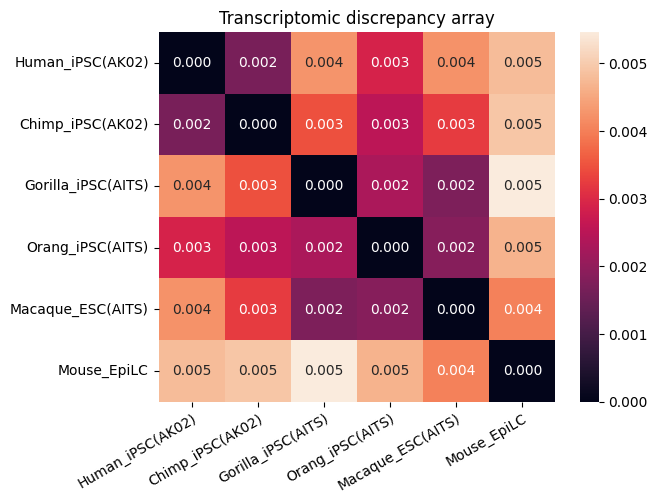

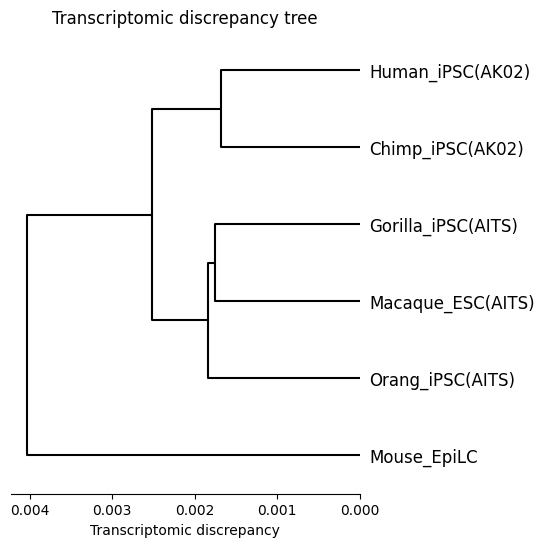

In [18]:
spe_ot.plot_transcriptomic_discrepancy()

## Chained Processing

In [19]:
data2 = Data(config).read_csv().normalization().read_tf()

start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(16535), '#non-significant genes': np.int64(15612), '#silent genes': np.int64(0), 'ell': np.int64(65), 'Elapsed time': '0h 0m 10s 926ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15569), '#non-significant genes': np.int64(12952), '#silent genes': np.int64(0), 'ell': np.int64(32), 'Elapsed time': '0h 0m 1s 810ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15118), '#non-significant genes': np.int64(14736), '#silent genes': np.int64(0), 'ell': np.int64(66), 'Elapsed time': '0h 0m 12s 064ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(14588), '#non-significant genes': np.int64(14096), '#silent genes': np.int64

epsilon = 0.1000000 converged


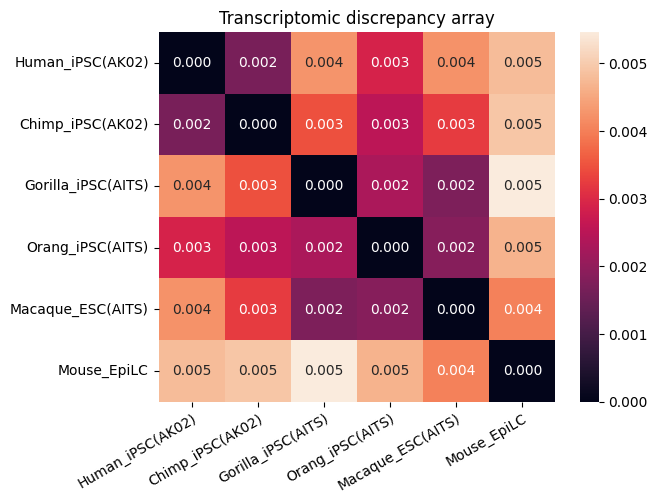

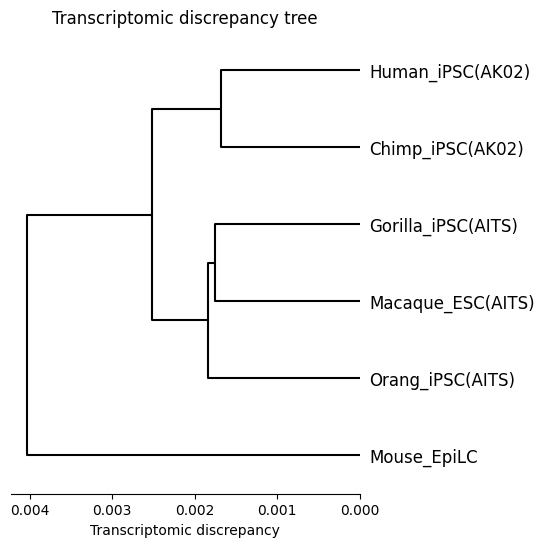

In [20]:
spe_ot2 = (
    SpeciesOT(data2)
    .preprocessing()
    .calculate_gene_distance_matrix()
    .gromov_wasserstein_ot()
    .normalize_otp()
    .plot_transcriptomic_discrepancy()
)

## End